# Ticket EDA - IT Operations Analytics

## Objective
Explore the final ticket dataset to understand business patterns, review key distributions, detect outliers, and identify useful insights for reporting and dashboard design.

## Scope
The analysis focuses on the final clean dataset:
- `data/final/tickets_final.csv`

Main areas:
- dataset overview
- ticket volume patterns
- priority distribution
- status distribution
- SLA time variables
- resolution time outliers
- business insights
- Power BI visual ideas

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# visual style
sns.set(style="whitegrid")

## 1. Setup and data loading
Load the final dataset and prepare the environment for exploratory analysis.

In [62]:
df = pd.read_csv("../data/final/tickets_final.csv", encoding="utf-8-sig")

In [63]:
df.head()

,ticket_id,ticket_code,created_at,assigned_at,first_response_at,resolved_at,closed_at,status,priority_id,category_id,channel_id,assigned_agent_id,opened_group_id,escalated_flag,escalated_group_id,correct_target_group_id,wrong_escalation_flag,escalation_returned_flag,missing_minimum_data_flag,reopened_flag,reopen_count,user_claim_count,assignment_sla_target_min,action_sla_target_min,assignment_minutes,first_response_minutes,action_minutes,total_duration_minutes,assignment_sla_breached,action_sla_breached,time_to_first_response_min,time_to_resolution_min,time_to_close_min,is_outlier_resolution
0,1,INC-2025-000001,2025-01-01 09:47:17,2025-01-01 09:53:21,2025-01-01 09:50:28,2025-01-01 14:33:58,2025-01-03 12:40:58,Resolved,2,3,1,9,1,0,NaN,NaN,0,0,0,0,0,0,10,45,6.08,3.19,48.14,3053.69,0,1,3.183333,286.683333,3053.683333,False
1,2,INC-2025-000002,2025-01-01 10:02:46,2025-01-01 10:04:24,2025-01-01 10:03:47,2025-01-01 21:13:13,2025-01-02 07:07:13,Closed,2,5,4,1,1,1,4.0,4.0,0,0,0,0,0,0,10,45,1.64,1.02,27.47,1264.46,0,0,1.016667,670.450000,1264.450000,False
2,3,INC-2025-000003,2025-01-01 11:59:40,2025-01-01 12:00:40,2025-01-01 12:00:40,2025-01-01 14:29:56,2025-01-03 02:31:56,Closed,3,8,1,9,1,0,NaN,NaN,0,0,0,0,0,0,20,120,1.00,1.00,82.77,2312.28,0,0,1.000000,150.266667,2312.266667,False
3,4,INC-2025-000004,2025-01-01 18:08:32,2025-01-01 18:12:48,2025-01-01 18:11:15,2025-01-02 07:39:08,2025-01-03 05:24:08,Closed,4,6,3,2,1,0,NaN,NaN,0,0,0,0,0,2,30,30,4.27,2.73,8.76,2115.60,0,0,2.716667,810.600000,2115.600000,False
4,5,INC-2025-000005,2025-01-01 11:10:34,2025-01-01 11:32:52,2025-01-01 11:34:52,2025-01-02 07:59:25,2025-01-03 11:36:25,Closed,5,13,4,7,1,1,2.0,2.0,0,0,0,0,0,0,60,240,22.31,24.30,54.83,2905.85,0,0,24.300000,1248.850000,2905.850000,False


### Problems found

- CSV delimiter mismatch (expected ;, actual ,)
- Data loaded as a single column

### Changes made

- Removed incorrect separator parameter
- Loaded dataset with correct default delimiter

## 2. Data overview
Review the dataset structure, size, columns, data types, and general completeness.

In [64]:
df.shape

(70985, 34)

In [65]:
df.columns

Index(['ticket_id', 'ticket_code', 'created_at', 'assigned_at', 'first_response_at', 'resolved_at', 'closed_at', 'status', 'priority_id', 'category_id', 'channel_id', 'assigned_agent_id', 'opened_group_id', 'escalated_flag', 'escalated_group_id', 'correct_target_group_id', 'wrong_escalation_flag', 'escalation_returned_flag', 'missing_minimum_data_flag', 'reopened_flag', 'reopen_count', 'user_claim_count', 'assignment_sla_target_min', 'action_sla_target_min', 'assignment_minutes', 'first_response_minutes', 'action_minutes', 'total_duration_minutes', 'assignment_sla_breached', 'action_sla_breached', 'time_to_first_response_min', 'time_to_resolution_min', 'time_to_close_min', 'is_outlier_resolution'], dtype='str')

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70985 entries, 0 to 70984
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ticket_id                   70985 non-null  int64  
 1   ticket_code                 70985 non-null  str    
 2   created_at                  70985 non-null  str    
 3   assigned_at                 70985 non-null  str    
 4   first_response_at           70700 non-null  str    
 5   resolved_at                 69635 non-null  str    
 6   closed_at                   70823 non-null  str    
 7   status                      70985 non-null  str    
 8   priority_id                 70985 non-null  int64  
 9   category_id                 70985 non-null  int64  
 10  channel_id                  70985 non-null  int64  
 11  assigned_agent_id           70985 non-null  int64  
 12  opened_group_id             70985 non-null  int64  
 13  escalated_flag              70985 non-null

In [67]:
df.isnull().sum().sort_values(ascending=False)

correct_target_group_id       51921
escalated_group_id            51921
resolved_at                    1350
time_to_resolution_min         1350
first_response_minutes          285
time_to_first_response_min      285
first_response_at               285
closed_at                       162
time_to_close_min               162
ticket_id                         0
ticket_code                       0
priority_id                       0
channel_id                        0
assigned_agent_id                 0
category_id                       0
status                            0
created_at                        0
assigned_at                       0
escalation_returned_flag          0
wrong_escalation_flag             0
opened_group_id                   0
escalated_flag                    0
user_claim_count                  0
missing_minimum_data_flag         0
reopen_count                      0
reopened_flag                     0
assignment_minutes                0
action_sla_target_min       

In [68]:
df.describe()

,ticket_id,priority_id,category_id,channel_id,assigned_agent_id,opened_group_id,escalated_flag,escalated_group_id,correct_target_group_id,wrong_escalation_flag,escalation_returned_flag,missing_minimum_data_flag,reopened_flag,reopen_count,user_claim_count,assignment_sla_target_min,action_sla_target_min,assignment_minutes,first_response_minutes,action_minutes,total_duration_minutes,assignment_sla_breached,action_sla_breached,time_to_first_response_min,time_to_resolution_min,time_to_close_min
count,70985.000000,70985.000000,70985.000000,70985.000000,70985.000000,70985.0,70985.000000,19064.000000,19064.000000,70985.000000,70985.000000,70985.000000,70985.000000,70985.000000,70985.000000,70985.000000,70985.000000,70985.000000,70700.000000,70985.000000,70985.000000,70985.000000,70985.000000,70700.000000,69635.000000,70823.000000
mean,35493.000000,3.515193,6.119039,2.023766,6.120068,1.0,0.268564,4.263638,4.247010,0.026090,0.056279,0.038304,0.047080,0.057759,0.174882,28.198422,82.259210,11.008047,8.029707,56.855000,2911.316597,0.061083,0.157526,8.023745,873.134318,2911.557728
std,20491.748766,1.027966,3.830667,1.101985,3.492819,0.0,0.443216,1.696740,1.685742,0.159404,0.230462,0.191930,0.211812,0.280202,0.535364,15.022045,73.840552,15.484920,11.871533,110.947979,1890.916741,0.239485,0.364299,11.871162,1622.551205,1891.260039
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,15.000000,1.000000,1.000000,2.000000,8.580000,0.000000,0.000000,1.000000,3.316667,8.566667
25%,17747.000000,3.000000,3.000000,1.000000,3.000000,1.0,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,30.000000,3.040000,2.030000,11.700000,1595.740000,0.000000,0.000000,2.016667,222.258333,1596.441667
50%,35493.000000,4.000000,6.000000,2.000000,6.000000,1.0,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,45.000000,6.510000,4.460000,24.430000,2766.510000,0.000000,0.000000,4.450000,413.766667,2766.650000
75%,53239.000000,4.000000,9.000000,3.000000,9.000000,1.0,1.000000,5.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,120.000000,13.100000,9.350000,62.090000,3920.730000,0.000000,0.000000,9.350000,779.591667,3920.775000
max,70985.000000,5.000000,14.000000,5.000000,12.000000,1.0,1.000000,8.000000,8.000000,1.000000,1.000000,1.000000,1.000000,3.000000,4.000000,60.000000,240.000000,381.790000,304.480000,4155.830000,41690.190000,1.000000,1.000000,304.466667,37846.183333,41690.183333


### Observations

- The dataset contains around 70k tickets with consistent structure.
- Data types are correctly defined for analysis.
- Missing values are mainly related to escalation fields and unresolved tickets.
- SLA-related fields are available and ready for analysis.
- Resolution time shows high variability, indicating possible outliers.

### Problems found

- Missing values in escalation-related fields (expected behavior)
- Some SLA fields contain null values for unresolved tickets

### Changes made

- Validated dataset structure and completeness
- Confirmed SLA fields availability
- Identified potential outliers in resolution time

## 3. Ticket volume analysis (by priority)
Analyze how ticket volume is distributed across key business dimensions.

In [89]:
tickets_by_priority = df["priority_id"].value_counts().sort_index()
tickets_by_priority

priority_id
1     3307
2     8733
3    17013
4    31946
5     9986
Name: count, dtype: int64

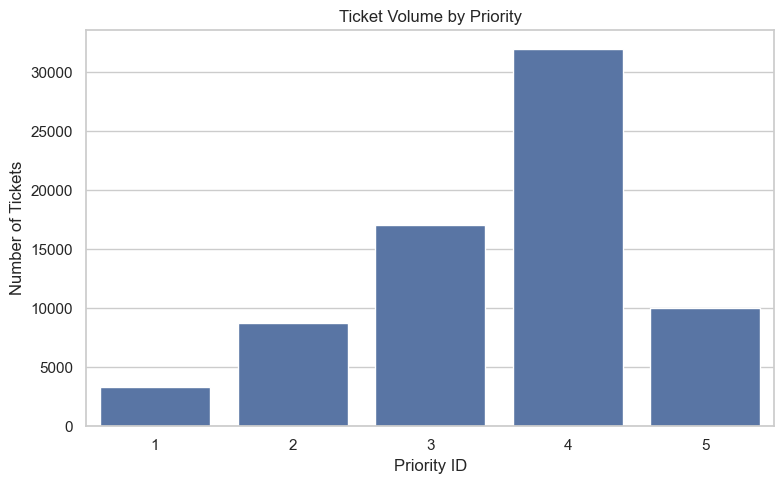

In [590]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=tickets_by_priority.index,
    y=tickets_by_priority.values
)

plt.title("Ticket Volume by Priority")
plt.xlabel("Priority ID")
plt.ylabel("Number of Tickets")

plt.tight_layout()
plt.savefig("../reports/visuals/ticket_volume_by_priority.png", dpi=300, bbox_inches="tight")

plt.show()

In [624]:
tickets_by_priority_pct = df["priority_id"].value_counts(normalize=True).sort_index() * 100
tickets_by_priority_pct

priority_id
1     4.658731
2    12.302599
3    23.967035
4    45.003874
5    14.067761
Name: proportion, dtype: float64

### Observations

- Most tickets are concentrated in priority 4, representing the largest workload segment.
- High priority tickets (1 and 2) represent a smaller percentage of total volume.
- The distribution suggests a stable support operation with controlled critical incidents.
- Medium priorities dominate, indicating a typical operational workload.

### Problems found

- No initial visibility of ticket distribution by priority

### Changes made

- Analyzed ticket volume by priority
- Created first business visualization
- Calculated percentage distribution for better interpretation

## 4. Priority analysis
Understand the distribution of ticket priority levels and their business impact.

In [625]:
df.groupby("priority_id")[[
    "time_to_first_response_min",
    "time_to_resolution_min",
    "time_to_close_min"
]].mean()

,time_to_first_response_min,time_to_resolution_min,time_to_close_min
priority_id,,,
1,1.797436,606.844142,2692.752872
2,2.926899,904.590401,2941.995898
3,5.640091,876.077611,2909.084344
4,8.480639,847.081041,2886.226739
5,17.144535,1011.853440,3042.552715


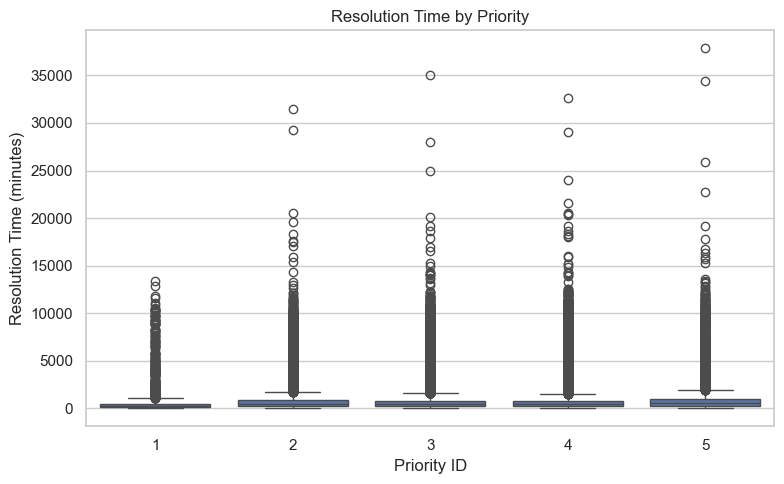

In [656]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="priority_id",
    y="time_to_resolution_min",
    data=df
)

plt.title("Resolution Time by Priority")
plt.xlabel("Priority ID")
plt.ylabel("Resolution Time (minutes)")

plt.tight_layout()
plt.savefig("../reports/visuals/resolution_time_by_priority.png", dpi=300, bbox_inches="tight")

plt.show()

### Observations

- Resolution time shows high variability across all priority levels.
- Median resolution time is relatively similar between priorities.
- A large number of outliers are present in every priority group.
- Priority alone does not fully explain resolution time differences.
- Other operational factors may have a strong impact on performance.

### Problems found

- Resolution time variability is high across all priority levels
- Presence of significant outliers in all priority groups

### Changes made

- Analyzed SLA time metrics by priority
- Created boxplot visualization to explore resolution time distribution
- Identified that priority alone does not fully explain resolution time behavior

## 5. Status analysis
Review ticket status distribution to understand process outcomes.

In [657]:
df["status"].value_counts()

status
Closed       38253
Resolved     31384
Cancelled     1348
Name: count, dtype: int64

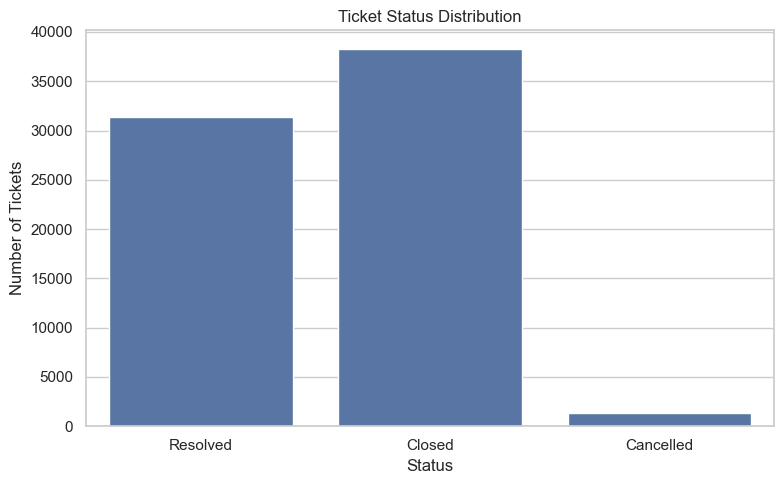

In [686]:
plt.figure(figsize=(8,5))

sns.countplot(x="status", data=df)

plt.title("Ticket Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Tickets")

plt.tight_layout()
plt.savefig("../reports/visuals/ticket_status_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observations

- Most tickets are in Closed and Resolved status, indicating a high completion rate.
- Cancelled tickets represent a very small portion of the dataset.
- The support process appears stable with minimal ticket abandonment.
- The distribution suggests a well-functioning ticket lifecycle.

## 6. SLA time variables analysis
Explore the main SLA-related time fields and review their distributions.

In [687]:
df[[
    "time_to_first_response_min",
    "time_to_resolution_min",
    "time_to_close_min"
]].describe().loc[["mean", "50%", "max"]].round(2)

,time_to_first_response_min,time_to_resolution_min,time_to_close_min
mean,8.02,873.13,2911.56
50%,4.45,413.77,2766.65
max,304.47,37846.18,41690.18


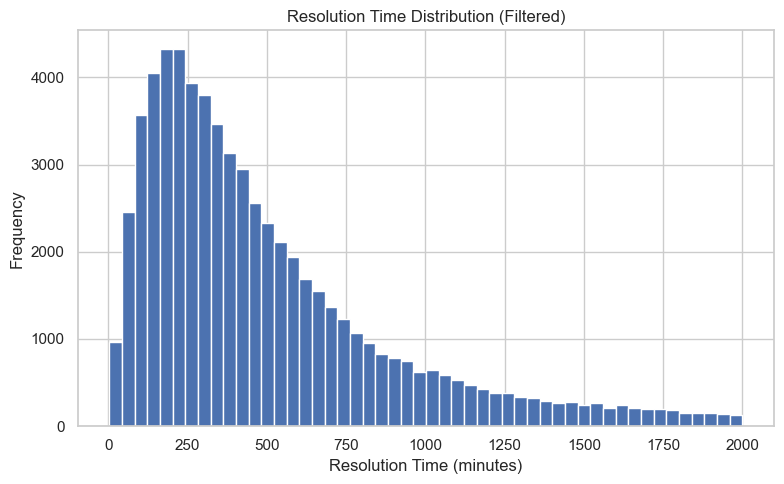

In [714]:
plt.figure(figsize=(8,5))

df[df["time_to_resolution_min"] < 2000]["time_to_resolution_min"].hist(bins=50)

plt.title("Resolution Time Distribution (Filtered)")
plt.xlabel("Resolution Time (minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("../reports/visuals/resolution_time_distribution_filtered.png", dpi=300, bbox_inches="tight")

plt.show()

### Observations

- After filtering extreme values, the distribution becomes much clearer.
- Most tickets are resolved within a consistent time range.
- A peak is observed around the typical operational resolution window.
- The long tail indicates that some tickets still require significantly more time.
- Filtering outliers helps reveal the true operational behavior.

### Problems found

- Extreme outliers distorted the original histogram
- Main data distribution was not clearly visible

### Changes made

- Filtered resolution time to focus on relevant range
- Improved visualization clarity
- Revealed the true distribution of resolution times

## 7. Resolution time outlier analysis
Detect unusual resolution times and evaluate their possible business meaning.

In [715]:
q1 = df["time_to_resolution_min"].quantile(0.25)
q3 = df["time_to_resolution_min"].quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

outliers = df[df["time_to_resolution_min"] > upper_bound]

outliers.shape

(7162, 34)

In [716]:
outlier_pct = (len(outliers) / len(df)) * 100
outlier_pct

10.08945551877157

In [717]:
outliers[[
    "ticket_id",
    "priority_id",
    "time_to_resolution_min",
    "status"
]].head(10)

,ticket_id,priority_id,time_to_resolution_min,status
35,36,4,4042.450000,Closed
49,50,4,4527.766667,Resolved
67,68,4,7370.150000,Resolved
124,125,3,3403.600000,Closed
132,133,3,2908.366667,Closed
164,165,3,6812.316667,Resolved
168,169,4,2408.450000,Resolved
169,170,3,2224.600000,Resolved
187,188,4,11223.633333,Resolved
239,240,2,9721.500000,Resolved


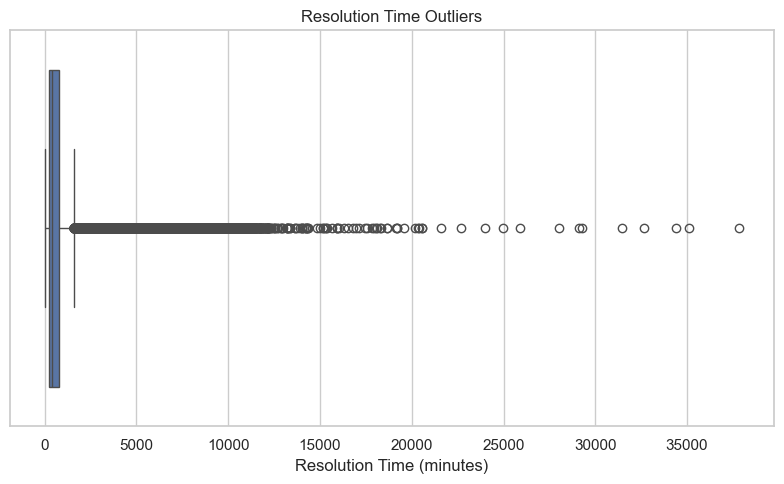

In [740]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["time_to_resolution_min"])

plt.title("Resolution Time Outliers")
plt.xlabel("Resolution Time (minutes)")

plt.tight_layout()
plt.savefig("../reports/visuals/resolution_time_outliers_full.png", dpi=300, bbox_inches="tight")

plt.show()

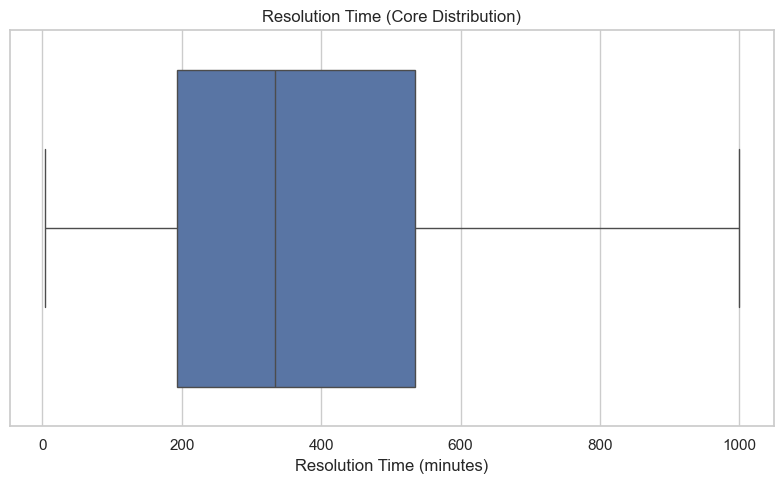

In [762]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df[df["time_to_resolution_min"] < 1000]["time_to_resolution_min"],
    showfliers=False
)

plt.title("Resolution Time (Core Distribution)")
plt.xlabel("Resolution Time (minutes)")

plt.tight_layout()
plt.savefig("../reports/visuals/resolution_time_core_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Observations

- The full boxplot highlights a significant number of extreme values.
- These outliers affect the overall distribution and visualization.
- A filtered view provides a clearer understanding of the core behavior.
- Both views are necessary to fully understand the data.

### Problems found

- Outliers dominate the visualization in full-scale plots
- Central distribution is difficult to interpret without filtering

### Changes made

- Created both full and filtered boxplots
- Separated outlier analysis from core distribution analysis
- Improved clarity and interpretability of visualizations

## 8. Business insights
Summarize the most relevant findings from the exploratory analysis.

### Key business insights

- The majority of tickets are concentrated in medium priority levels, especially priority 4.
- SLA compliance is consistent across priorities, but resolution time variability is high.
- Around 10% of tickets show unusually high resolution times, indicating potential operational inefficiencies.
- Most tickets are successfully completed, with very low cancellation rates.
- Resolution time distribution is highly skewed, meaning average values may not represent typical performance.
- Outliers have a strong impact on SLA metrics and should be analyzed separately.

## 9. Power BI visual suggestions
List the most useful visuals that can be created later in Power BI based on the EDA findings.

### Power BI visualization suggestions

- KPI cards:
  - Total tickets
  - SLA compliance rate
  - Average resolution time
  - Reopen rate

- Bar charts:
  - Ticket volume by priority
  - SLA compliance by priority
  - Ticket volume by agent

- Line charts:
  - Ticket volume over time
  - SLA compliance trend over time

- Boxplots:
  - Resolution time by priority
  - Resolution time by agent

- Filters:
  - Priority
  - Status
  - Agent
  - Date range

- Tables:
  - Top agents by performance
  - Tickets with highest resolution time

# Tickets EDA and Validation

## Objective
Explore the cleaned dataset and check if it is ready for analysis.

## Scope
- Load processed dataset
- Check structure and data types
- Check missing values
- Validate date columns
- Explore key fields (SLA, priority, agents)
- Write basic insights

In [763]:
import os
print(os.getcwd())

c:\Users\m2002\Documents\Proyectos  Propios\IT-Operations-Analytics\notebooks


In [764]:
df = pd.read_csv("../data/processed/tickets.csv", encoding="utf-8-sig")

In [765]:
df.head()

,ticket_id,ticket_code,created_at,assigned_at,first_response_at,resolved_at,closed_at,status,priority_id,category_id,channel_id,assigned_agent_id,opened_group_id,escalated_flag,escalated_group_id,correct_target_group_id,wrong_escalation_flag,escalation_returned_flag,missing_minimum_data_flag,reopened_flag,reopen_count,user_claim_count,assignment_sla_target_min,action_sla_target_min,assignment_minutes,first_response_minutes,action_minutes,total_duration_minutes,assignment_sla_breached,action_sla_breached
0,1,INC-2025-000001,2025-01-01 09:47:17,2025-01-01 09:53:21,2025-01-01 09:50:28,2025-01-01 14:33:58,2025-01-03 12:40:58,Resolved,2,3,1,9,1,0,NaN,NaN,0,0,0,0,0,0,10,45,6.08,3.19,48.14,3053.69,0,1
1,2,INC-2025-000002,2025-01-01 10:02:46,2025-01-01 10:04:24,2025-01-01 10:03:47,2025-01-01 21:13:13,2025-01-02 07:07:13,Closed,2,5,4,1,1,1,4.0,4.0,0,0,0,0,0,0,10,45,1.64,1.02,27.47,1264.46,0,0
2,3,INC-2025-000003,2025-01-01 11:59:40,2025-01-01 12:00:40,2025-01-01 12:00:40,2025-01-01 14:29:56,2025-01-03 02:31:56,Closed,3,8,1,9,1,0,NaN,NaN,0,0,0,0,0,0,20,120,1.00,1.00,82.77,2312.28,0,0
3,4,INC-2025-000004,2025-01-01 18:08:32,2025-01-01 18:12:48,2025-01-01 18:11:15,2025-01-02 07:39:08,2025-01-03 05:24:08,Closed,4,6,3,2,1,0,NaN,NaN,0,0,0,0,0,2,30,30,4.27,2.73,8.76,2115.60,0,0
4,5,INC-2025-000005,2025-01-01 11:10:34,2025-01-01 11:32:52,2025-01-01 11:34:52,2025-01-02 07:59:25,2025-01-03 11:36:25,Closed,5,13,4,7,1,1,2.0,2.0,0,0,0,0,0,0,60,240,22.31,24.30,54.83,2905.85,0,0


In [766]:
df.shape

(70985, 30)

In [767]:
df.columns

Index(['ticket_id', 'ticket_code', 'created_at', 'assigned_at', 'first_response_at', 'resolved_at', 'closed_at', 'status', 'priority_id', 'category_id', 'channel_id', 'assigned_agent_id', 'opened_group_id', 'escalated_flag', 'escalated_group_id', 'correct_target_group_id', 'wrong_escalation_flag', 'escalation_returned_flag', 'missing_minimum_data_flag', 'reopened_flag', 'reopen_count', 'user_claim_count', 'assignment_sla_target_min', 'action_sla_target_min', 'assignment_minutes', 'first_response_minutes', 'action_minutes', 'total_duration_minutes', 'assignment_sla_breached', 'action_sla_breached'], dtype='str')

In [768]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70985 entries, 0 to 70984
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ticket_id                  70985 non-null  int64  
 1   ticket_code                70985 non-null  str    
 2   created_at                 70985 non-null  str    
 3   assigned_at                70985 non-null  str    
 4   first_response_at          70700 non-null  str    
 5   resolved_at                69635 non-null  str    
 6   closed_at                  70823 non-null  str    
 7   status                     70985 non-null  str    
 8   priority_id                70985 non-null  int64  
 9   category_id                70985 non-null  int64  
 10  channel_id                 70985 non-null  int64  
 11  assigned_agent_id          70985 non-null  int64  
 12  opened_group_id            70985 non-null  int64  
 13  escalated_flag             70985 non-null  int64  
 14  e

## Initial Structure Review

### Problems found:
- Date columns were stored as object
- Dataset path needed validation because the notebook runs from the `notebooks/` folder

### Changes made:
- Loaded processed dataset from the correct relative path
- Reviewed dataset structure, columns and data types

In [769]:
date_columns = [
    "created_at",
    "assigned_at",
    "first_response_at",
    "resolved_at",
    "closed_at"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [770]:
df[date_columns].info()

<class 'pandas.DataFrame'>
RangeIndex: 70985 entries, 0 to 70984
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   created_at         70985 non-null  datetime64[us]
 1   assigned_at        70985 non-null  datetime64[us]
 2   first_response_at  70700 non-null  datetime64[us]
 3   resolved_at        69635 non-null  datetime64[us]
 4   closed_at          70823 non-null  datetime64[us]
dtypes: datetime64[us](5)
memory usage: 2.7 MB


## Date Columns Validation

### Problems found:
- Main timestamp fields were not in datetime format

### Changes made:
- Converted date columns using `pd.to_datetime`
- Standardized date fields for SLA analysis

In [771]:
df["time_to_first_response_min"] = (
    df["first_response_at"] - df["created_at"]
).dt.total_seconds() / 60

df["time_to_resolution_min"] = (
    df["resolved_at"] - df["created_at"]
).dt.total_seconds() / 60

df["time_to_close_min"] = (
    df["closed_at"] - df["created_at"]
).dt.total_seconds() / 60

In [772]:
df[[
    "time_to_first_response_min",
    "time_to_resolution_min",
    "time_to_close_min"
]].describe()

,time_to_first_response_min,time_to_resolution_min,time_to_close_min
count,70700.000000,69635.000000,70823.000000
mean,8.023745,873.134318,2911.557728
std,11.871162,1622.551205,1891.260039
min,1.000000,3.316667,8.566667
25%,2.016667,222.258333,1596.441667
50%,4.450000,413.766667,2766.650000
75%,9.350000,779.591667,3920.775000
max,304.466667,37846.183333,41690.183333


## SLA Metrics Creation

### Problems found:
- SLA metrics were not available as analysis-ready fields

### Changes made:
- Created time to first response in minutes
- Created time to resolution in minutes
- Created time to close in minutes

In [773]:
(df["time_to_resolution_min"] < 0).sum()

np.int64(0)

In [774]:
df[df["time_to_resolution_min"] > 10080].shape

(418, 33)

In [775]:
df[df["time_to_resolution_min"] > 10080][[
    "ticket_id",
    "created_at",
    "resolved_at",
    "time_to_resolution_min",
    "priority_id"
]].head(10)

,ticket_id,created_at,resolved_at,time_to_resolution_min,priority_id
187,188,2025-01-01 11:49:43,2025-01-09 06:53:21,11223.633333,4
356,357,2025-01-02 09:46:02,2025-01-09 23:48:50,10922.800000,5
439,440,2025-01-03 12:14:12,2025-01-10 17:03:19,10369.116667,4
485,486,2025-01-03 14:06:51,2025-01-11 18:53:25,11806.566667,4
584,585,2025-01-03 14:45:12,2025-01-10 21:02:10,10456.966667,4
674,675,2025-01-04 12:25:25,2025-01-11 12:46:35,10101.166667,4
695,696,2025-01-04 13:16:55,2025-01-11 18:01:12,10364.283333,5
940,941,2025-01-06 10:28:17,2025-01-13 11:49:43,10161.433333,2
1018,1019,2025-01-06 11:50:26,2025-01-14 22:55:06,12184.666667,4
1048,1049,2025-01-06 11:16:16,2025-01-13 19:17:14,10560.966667,3


In [776]:
df["is_outlier_resolution"] = df["time_to_resolution_min"] > 10080

In [777]:
df["is_outlier_resolution"].value_counts()

is_outlier_resolution
False    70567
True       418
Name: count, dtype: int64

In [778]:
df[["resolved_at", "time_to_resolution_min"]].head(20)

,resolved_at,time_to_resolution_min
0,2025-01-01 14:33:58,286.683333
1,2025-01-01 21:13:13,670.450000
2,2025-01-01 14:29:56,150.266667
3,2025-01-02 07:39:08,810.600000
4,2025-01-02 07:59:25,1248.850000
5,2025-01-01 21:02:33,274.433333
6,2025-01-01 13:56:19,261.850000
7,2025-01-02 05:46:19,997.116667
8,2025-01-01 21:37:59,498.500000
9,2025-01-02 09:38:03,1456.833333


## Resolution Time Validation

### Problems found:
- Some tickets have very high resolution times (more than 7 days)
- Resolution time outliers may indicate backlog or complex cases

### Changes made:
- Validated that there are no negative resolution times
- Reviewed outlier cases above 7 days
- Created an outlier flag for long resolution times
- Confirmed that resolution timestamps and calculated metrics are logically consistent

In [779]:
df["status"].value_counts()

status
Closed       38253
Resolved     31384
Cancelled     1348
Name: count, dtype: int64

In [780]:
df["priority_id"].value_counts().sort_index()

priority_id
1     3307
2     8733
3    17013
4    31946
5     9986
Name: count, dtype: int64

In [781]:
df["assigned_agent_id"].nunique()

12

## Business Fields Validation

### Problems found:
- No inconsistencies were found in core business fields

### Changes made:
- Validated status distribution
- Validated priority distribution
- Verified assigned agent coverage

In [782]:
df.to_csv("../data/final/tickets_final.csv", index=False, encoding="utf-8-sig")

## Final Dataset Creation

### Problems found:
- The processed dataset was not yet ready for direct analysis
- SLA metrics were missing before notebook validation

### Changes made:
- Loaded processed dataset
- Converted date columns to datetime
- Created SLA metrics
- Validated data consistency
- Identified outliers in resolution time
- Validated business fields
- Saved final dataset version in `data/final/tickets_final.csv`

## Final Insights

### Key insights
- Date columns are now standardized and ready for time-based analysis
- SLA metrics are available for response, resolution and closure analysis
- No negative resolution times were found
- A small number of tickets show very long resolution times, which may represent backlog or complex incidents
- Core business fields such as status, priority and assigned agent look consistent

### Result
The dataset is clean, consistent and ready for SQL analysis and Power BI.